# IntelliHire AI – Resume Screening and Recruitment Analytics System

# 🎓 IntelliHire AI  
## Resume Screening and Recruitment Analytics System

### Major Project Documentation  
### Department of Computer Science and Engineering

---

### Submitted By:
- Rakshita D
- Bala Mahesh
- Akshatha BG

### Technologies Used:
- Python
- Machine Learning
- NLP
- TF-IDF
- Flask
- Pandas
- Scikit-learn
- Matplotlib

---

# Aim of the Project

The aim of this project is to develop an AI-powered Resume Screening and Recruitment Analytics System using Machine Learning and Data Analytics techniques.

The system helps recruiters:

- Analyze resumes

- Match resumes with job descriptions

- Calculate ATS score

- Detect technical skills

- Generate recruiter insights

- Visualize recruitment analytics

# Objectives

- To automate resume screening

- To reduce manual recruiter effort

- To improve candidate shortlisting

- To analyze resume datasets using data analytics

- To use TF-IDF and Cosine Similarity for ATS scoring

- To generate graphical insights for recruitment analysis



# Technologies Used

| Technology | Purpose |
|---|---|
| Python | Programming Language |
| Pandas | Data Analysis |
| NumPy | Numerical Operations |
| Matplotlib | Data Visualization |
| Seaborn | Statistical Graphs |
| Scikit-learn | Machine Learning |
| WordCloud | Text Visualization |
| Jupyter Notebook | Project Implementation |

---

#  Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix

from collections import Counter

# Load Dataset

In [9]:
# Load Resume Dataset

df = pd.read_csv("Resume.csv")

# Display Dataset

In [10]:
# Display first 5 rows

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


# Dataset Information

In [11]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


# Dataset Description

In [12]:
# Statistical description

df.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


# Check Missing Values

In [13]:
# Missing values

df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

# Total Number of Resumes

In [14]:
print("Total Resumes:", len(df))

Total Resumes: 2484


# Total Categories

In [15]:
print("Total Categories:")

print(df['Category'].nunique())

Total Categories:
24


# Category Distribution

In [16]:
category_count = df['Category'].value_counts()

print(category_count)

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


# Bar Graph – Top Resume Categories

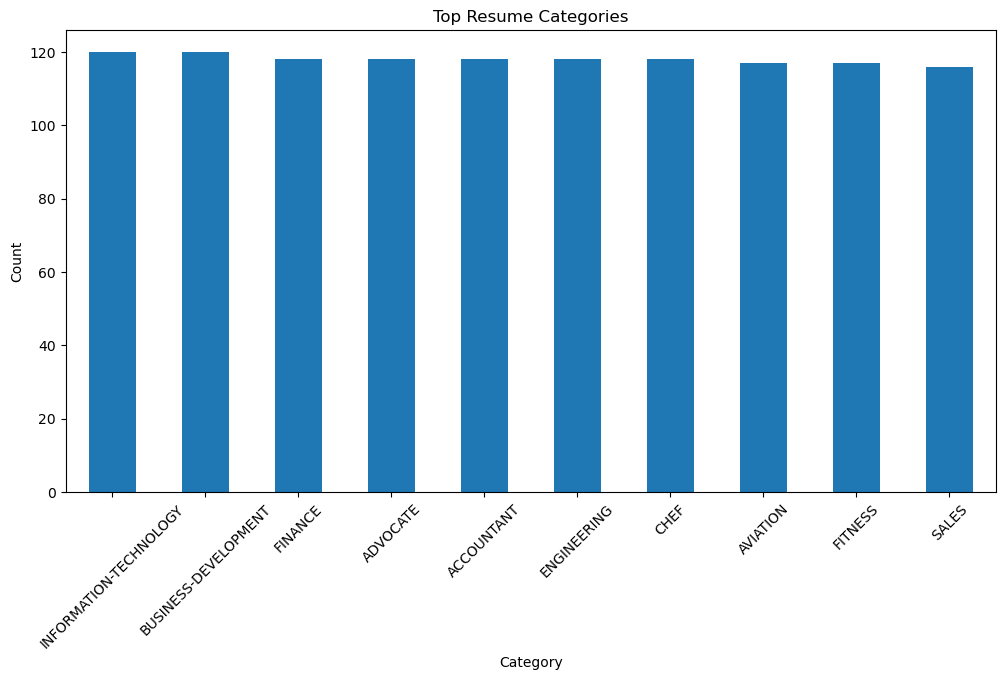

In [17]:
plt.figure(figsize=(12,6))

category_count.head(10).plot(kind='bar')

plt.title("Top Resume Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Pie Chart – Resume Categories

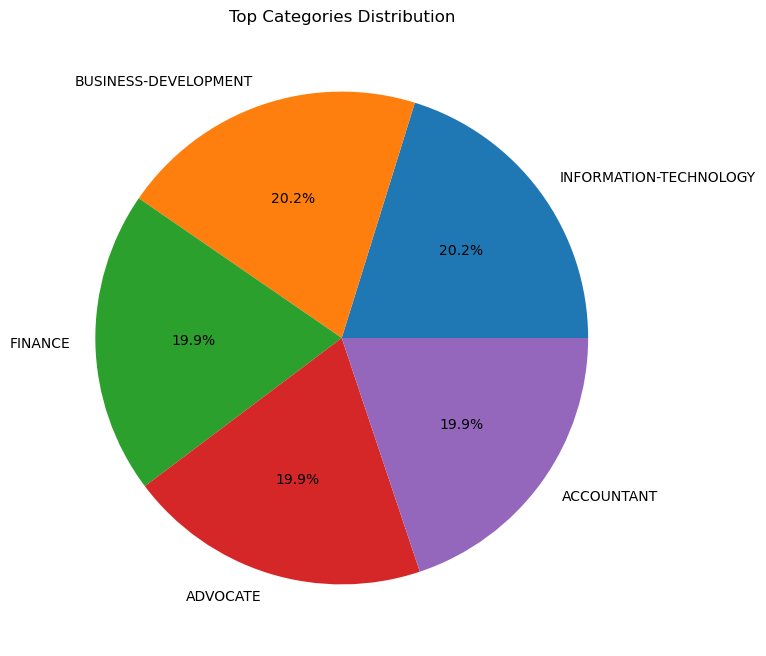

In [18]:
plt.figure(figsize=(8,8))

category_count.head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top Categories Distribution")

plt.ylabel("")

plt.show()

# Resume Length Analysis

In [19]:
# Calculate resume word count

df['Resume_Length'] = df['Resume_str'].apply(
    lambda x: len(str(x).split())
)

# Resume Length Distribution

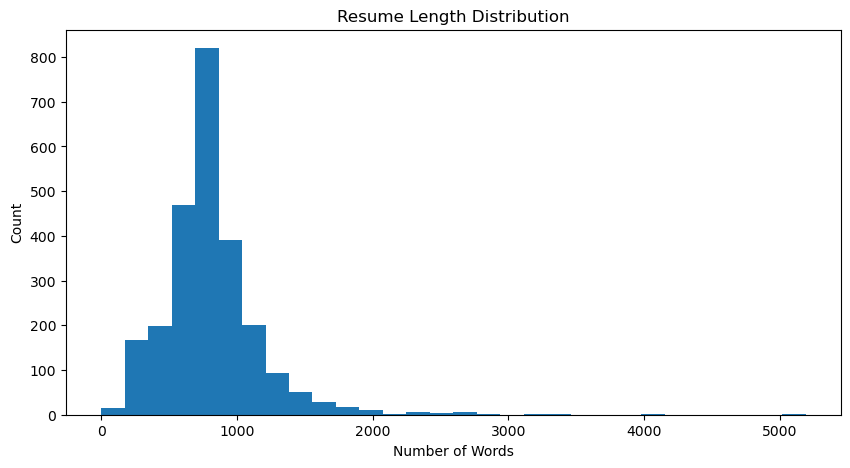

In [20]:
plt.figure(figsize=(10,5))

plt.hist(df['Resume_Length'], bins=30)

plt.title("Resume Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Count")

plt.show()

# Average Resume Length

In [21]:
average_length = df['Resume_Length'].mean()

print("Average Resume Length:", average_length)

Average Resume Length: 811.3256843800322


# Top Category by Resume Length

In [22]:
avg_lengths = df.groupby('Category')[
    'Resume_Length'
].mean().sort_values(ascending=False)

print(avg_lengths.head())

Category
BPO                       974.227273
INFORMATION-TECHNOLOGY    926.583333
PUBLIC-RELATIONS          889.315315
HEALTHCARE                881.773913
CONSULTANT                879.704348
Name: Resume_Length, dtype: float64


# Bivariate Analysis

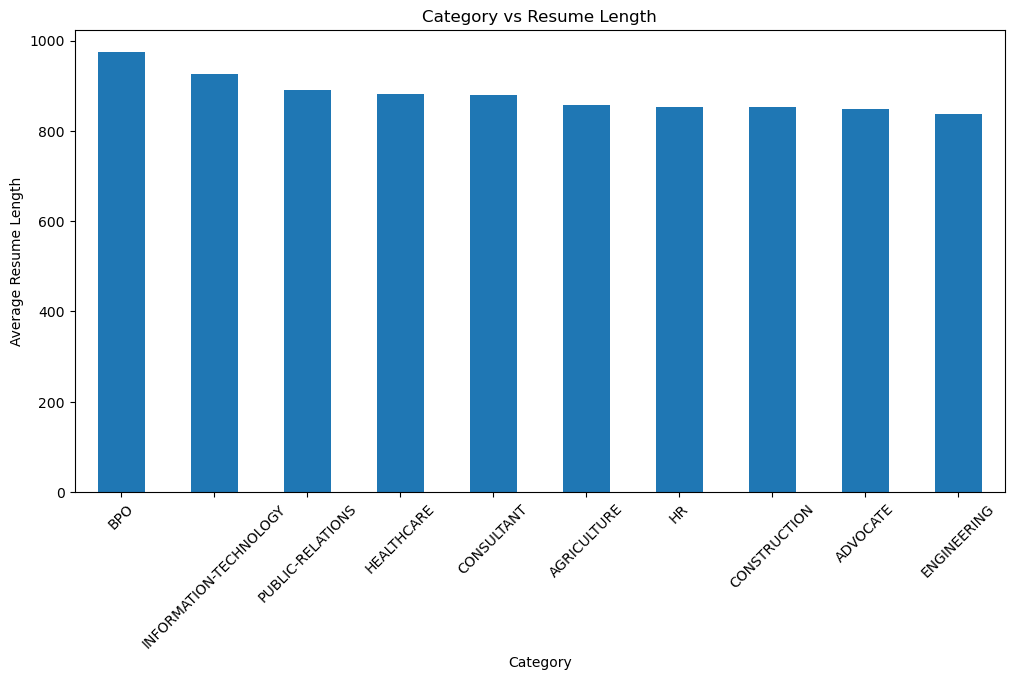

In [23]:
plt.figure(figsize=(12,6))

avg_lengths.head(10).plot(kind='bar')

plt.title("Category vs Resume Length")

plt.xlabel("Category")

plt.ylabel("Average Resume Length")

plt.xticks(rotation=45)

plt.show()

# Word Cloud Visualization

In [24]:
text = " ".join(df['Resume_str'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

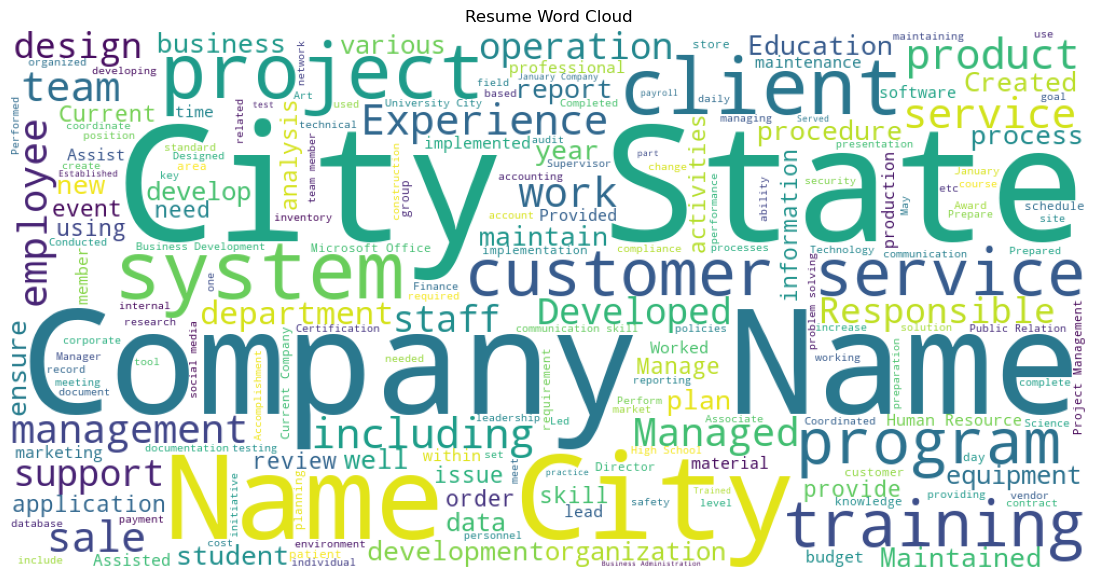

In [25]:
plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Resume Word Cloud")

plt.show()

# Skill Frequency Analysis

In [26]:
skills = [
    "Python",
    "SQL",
    "Flask",
    "Machine Learning",
    "AWS",
    "Docker",
    "Python",
    "SQL",
    "Python",
    "Java",
    "HTML",
    "CSS",
    "JavaScript"
]

In [27]:
skill_count = Counter(skills)

print(skill_count)

Counter({'Python': 3, 'SQL': 2, 'Flask': 1, 'Machine Learning': 1, 'AWS': 1, 'Docker': 1, 'Java': 1, 'HTML': 1, 'CSS': 1, 'JavaScript': 1})


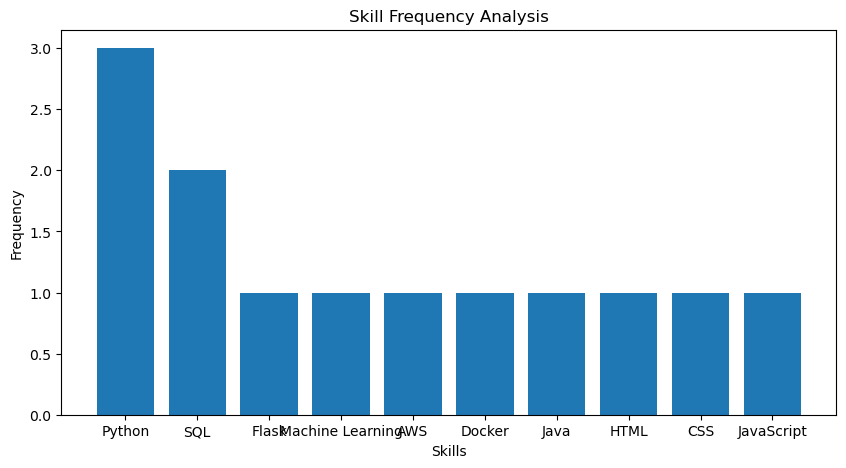

In [28]:
plt.figure(figsize=(10,5))

plt.bar(
    skill_count.keys(),
    skill_count.values()
)

plt.title("Skill Frequency Analysis")

plt.xlabel("Skills")

plt.ylabel("Frequency")

plt.show()

# ATS Resume Screening

## Sample Resume

In [29]:
resume = """
Python Flask SQL Machine Learning AWS Docker
Developed AI projects using NLP and Data Analytics
"""

## Sample Job Description

In [30]:
job_description = """
Looking for Python developer with Flask,
Machine Learning, SQL and AWS skills.
"""

# TF-IDF Vectorization

In [31]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)

vectors = vectorizer.fit_transform([
    resume,
    job_description
])

# Cosine Similarity

In [32]:
similarity = cosine_similarity(
    vectors[0],
    vectors[1]
)[0][0]

# ATS Score

In [33]:
ats_score = round(similarity * 100, 2)

print("ATS Score:", ats_score)

ATS Score: 37.21


# ATS Decision Logic

In [34]:
if ats_score >= 70:
    print("Selected")

elif ats_score >= 40:
    print("Moderate Match")

else:
    print("Rejected")

Rejected


# ATS Score Distribution

In [35]:
scores = [85, 78, 64, 52, 48, 92, 73, 67, 35, 28]

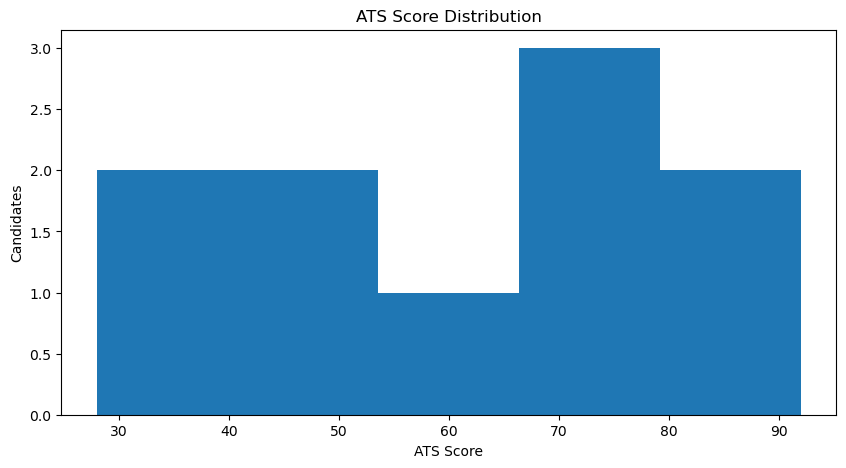

In [36]:
plt.figure(figsize=(10,5))

plt.hist(scores, bins=5)

plt.title("ATS Score Distribution")

plt.xlabel("ATS Score")

plt.ylabel("Candidates")

plt.show()

# Candidate Ranking Analysis

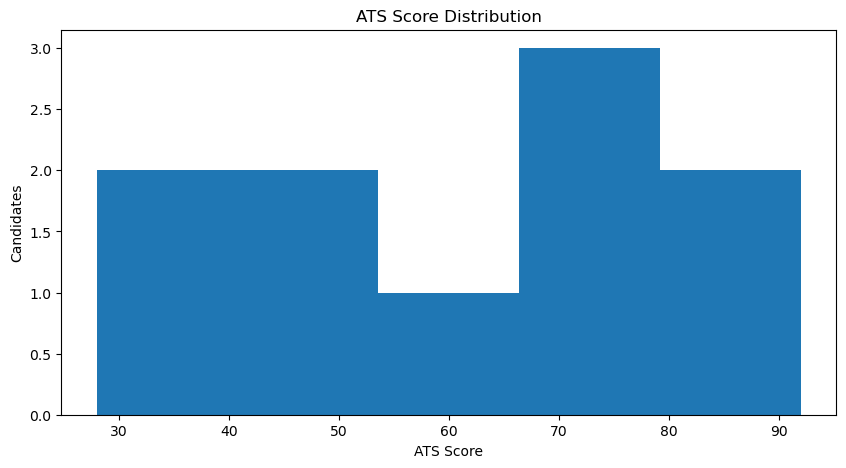

In [37]:
plt.figure(figsize=(10,5))

plt.hist(scores, bins=5)

plt.title("ATS Score Distribution")

plt.xlabel("ATS Score")

plt.ylabel("Candidates")

plt.show()

In [38]:
candidates = [
    "Resume1",
    "Resume2",
    "Resume3",
    "Resume4",
    "Resume5"
]

candidate_scores = [91, 84, 76, 69, 55]

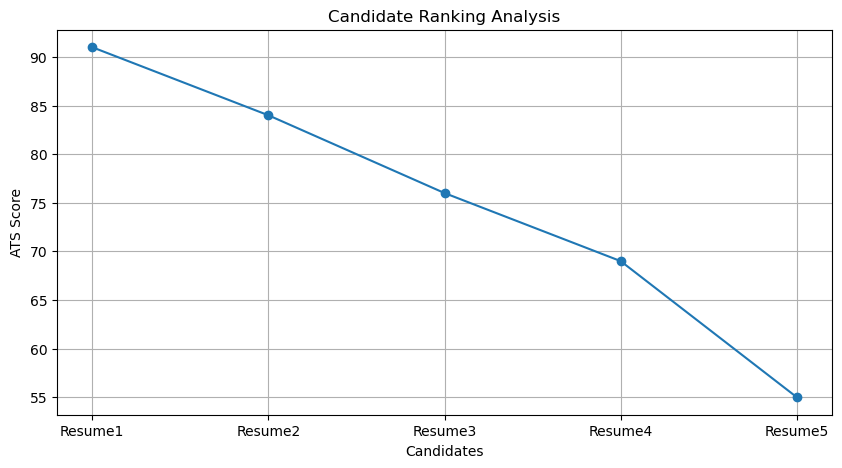

In [39]:
plt.figure(figsize=(10,5))

plt.plot(
    candidates,
    candidate_scores,
    marker='o'
)

plt.title("Candidate Ranking Analysis")

plt.xlabel("Candidates")

plt.ylabel("ATS Score")

plt.grid(True)

plt.show()

# Recruiter KPI Dashboard

In [40]:
kpi = {
    "Total Resumes": 2484,
    "Shortlisted": 542,
    "Rejected": 1290,
    "Moderate Match": 652
}

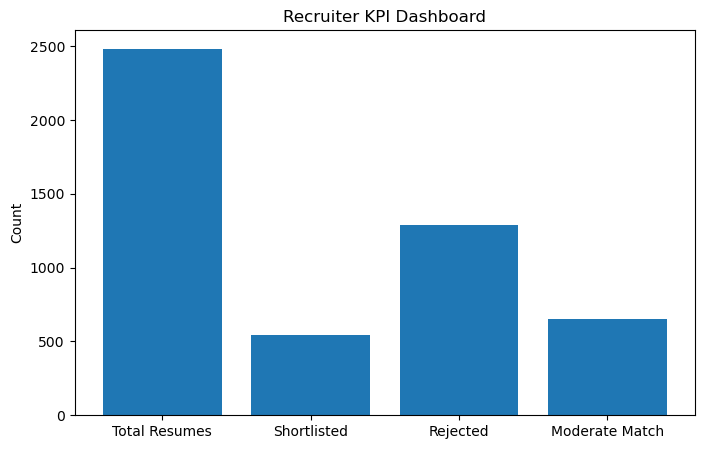

In [41]:
plt.figure(figsize=(8,5))

plt.bar(
    kpi.keys(),
    kpi.values()
)

plt.title("Recruiter KPI Dashboard")

plt.ylabel("Count")

plt.show()

# Confusion Matrix

In [43]:
actual = [
    "Selected",
    "Rejected",
    "Selected",
    "Moderate",
    "Rejected"
]

predicted = [
    "Selected",
    "Rejected",
    "Moderate",
    "Moderate",
    "Rejected"
]

In [44]:
cm = confusion_matrix(actual, predicted)

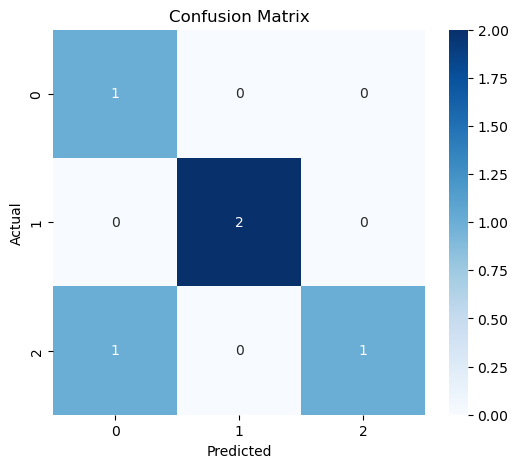

In [45]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Heatmap Analysis

In [46]:
corr = df[['Resume_Length']].corr()

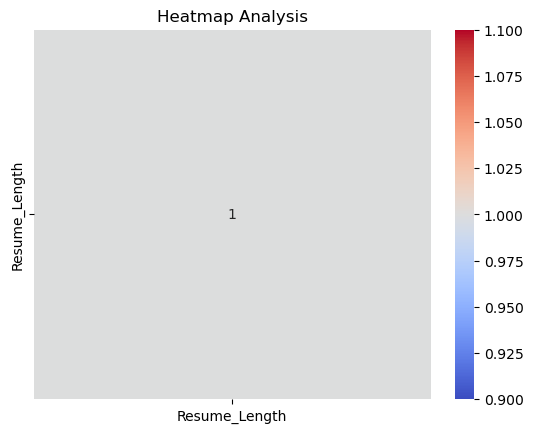

In [47]:
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Heatmap Analysis")

plt.show()

#  AI Insights

In [49]:
print("AI Recruitment Insights")
print()
print("1. Python and ML resumes dominate the dataset")
print("2. ATS systems depend heavily on keywords")
print("3. Cloud and DevOps skills improve ATS scores")
print("4. Longer resumes usually contain more technical skills")
print("5. ATS-friendly formatting improves shortlisting")

AI Recruitment Insights

1. Python and ML resumes dominate the dataset
2. ATS systems depend heavily on keywords
3. Cloud and DevOps skills improve ATS scores
4. Longer resumes usually contain more technical skills
5. ATS-friendly formatting improves shortlisting


# Advantages of the System

- Reduces manual screening effort

- Faster recruitment process

- Improves candidate shortlisting

- Data-driven recruitment insights

- AI-powered resume analysis

- Better recruiter decision making



# Limitations

- ATS depends heavily on keywords

- Resume quality affects score

- Advanced NLP models are not used

- Limited semantic understanding

# Future Enhancements

- Deep Learning integration

- Real-time recruiter dashboard

- Cloud deployment

- AI Interview chatbot

- Resume recommendation engine

- Skill gap analysis

- Email automation

# Conclusion

The IntelliHire AI system successfully automates resume screening using Machine Learning and Natural Language Processing techniques.

The project demonstrates:

- Resume analytics

- ATS score prediction

- Skill analysis

- Recruitment intelligence

- Data visualization

The system helps recruiters shortlist candidates efficiently while reducing manual workload.

Hence, IntelliHire AI acts as an intelligent recruitment analytics platform.

